## 1.1 Probing the article HTML scraping idea

In notebook 1.0 we found three limits in the raw corpus. Summaries are short, around 50 tokens. The `source` label is misleading because Yahoo, which is 72% of the corpus, reposts other outlets' stories under its own name. And that same reposting can hide the real publish time: the timestamp we have may be Yahoo's repost time rather than the original outlet's first publish, which sits on the source page. We noted one idea that could fix all three at once: follow each article's `url`, fetch the page HTML, and read the full body, the real publisher, and the true publish time from it.

That was left as a direction worth testing rather than a settled plan. This notebook is that test. It is a probe, not a finished scraper. We take a small sample of articles from different sources, try to fetch each one, and record what comes back: whether the page loads, who really published it, and the time it states. We report what works, what does not, and why. The plan runs in three parts. First a small probe, a handful of articles from each source, to judge whether fetching is worth it at all and which sources let us in. Then an evaluation of what it costs us, splitting the sources into open and closed and counting how many articles we drop when the closed ones go. Finally a larger sample run over the open sources, to probe source recovery, publish time, and body text in more depth.

### 1. Setup

We load the raw corpus and bring in `requests` for the fetch and `BeautifulSoup` for reading the HTML. Both are already in the project, so no new dependency is added. We send a normal browser User-Agent header, because some sites answer differently, or not at all, to a bare script.

In [7]:
import time
import json
import datetime as dt

import pandas as pd
import requests
from bs4 import BeautifulSoup
from dateutil import parser as date_parser

from stock_predictor.config import RAW_DATA_DIR

articles = pd.read_parquet(RAW_DATA_DIR / "raw_articles.parquet")

HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/124.0 Safari/537.36"
    )
}

print(f"Loaded {len(articles)} articles")

Loaded 3143 articles


### 2. Probing the pages

This section is the probe itself. We take a small sample of articles from each source, at most ten per source and fewer where a source has less, and run the probe on each one to read three things: the real publisher, the stated publish time, and how much body text comes back. From those results we judge each source and split them into two groups, open sources we can fully read and closed ones we cannot, and drop the closed sources so the rest of the work runs only on articles we can actually read. The steps below build up to that: first the redirect that makes recovery possible, then the probe function, then the run across all eight sources, and finally the split.

#### 2.1 The stored url is a Finnhub redirect, not the article

The first thing to notice is that the `url` we saved is not a link to the outlet. Every row points at `finnhub.io/api/news?id=...`, a Finnhub redirect. That is useful rather than a problem: following the redirect lands on the real page, and the final host tells us where the story actually lives. This is our first clue that the true publisher is recoverable.

In [8]:
articles[["source", "url"]].head(5)

,source,url
0,Benzinga,https://finnhub.io/api/news?id=9cebcac6e8a3e8d...
1,Benzinga,https://finnhub.io/api/news?id=a80ce533d3eee6e...
2,SeekingAlpha,https://finnhub.io/api/news?id=7bb14df67bd5441...
3,Benzinga,https://finnhub.io/api/news?id=f798ed9f2cbdaff...
4,Yahoo,https://finnhub.io/api/news?id=6706e1dfdcf600a...


In [9]:
sample_url = articles.loc[articles["source"] == "Yahoo", "url"].iloc[0]
resp = requests.get(sample_url, headers=HEADERS, timeout=20)

print("stored url :", sample_url)
print("final url  :", resp.url)
print("final host :", resp.url.split("/")[2])

stored url : https://finnhub.io/api/news?id=6706e1dfdcf600a469bba901a5c73eab7669e16b3731b7d0802ce095bf24e133
final url  : https://finance.yahoo.com/news/analyst-tesla-tlsa-automotive-weakness-141330475.html
final host : finance.yahoo.com


#### 2.2 A probe function

We build one probe function on top of a few small readers. Each reader pulls a single thing off the page; the probe ties them together and catches every failure as a value, so one dead link never stops the run. We introduce the readers one at a time, then the probe last.

Most news sites embed a block of machine-readable data marked `application/ld+json`, and the fields we want, the publisher and the published time, usually sit inside it. This first helper yields each object on the page, flattening the case where the payload is a list, so the readers below can scan them the same way.

In [10]:
def _ld_json_objects(soup):
    """Yield each JSON-LD object on the page, flattening list payloads."""
    for tag in soup.find_all("script", type="application/ld+json"):
        try:
            data = json.loads(tag.string or "")
        except json.JSONDecodeError:
            continue
        for obj in (data if isinstance(data, list) else [data]):
            if isinstance(obj, dict):
                yield obj

Reads the published time. Most sites carry it in the JSON-LD `datePublished` field; where that is missing we fall back to the common `article:published_time` meta tag.

In [11]:
def _published_time(soup):
    """Read the published time from JSON-LD, or fall back to a meta tag."""
    for obj in _ld_json_objects(soup):
        if obj.get("datePublished"):
            return obj["datePublished"]
    meta = soup.find("meta", attrs={"property": "article:published_time"})
    return meta["content"] if meta and meta.get("content") else None

Reads the publisher named on the page. Same approach: the JSON-LD `publisher` name first, then the `og:site_name` meta tag as a fallback.

In [12]:
def _publisher(soup):
    """Read the real publisher named on the page."""
    for obj in _ld_json_objects(soup):
        pub = obj.get("publisher")
        if isinstance(pub, dict) and pub.get("name"):
            return pub["name"]
    meta = soup.find("meta", attrs={"property": "og:site_name"})
    return meta["content"] if meta and meta.get("content") else None

Joins every paragraph on the page into one string. This is a rough body, boilerplate and all, and its length tells us how much text a fetch actually returned.

In [13]:
def _body_text(soup):
    """Join the page's paragraph text into one string."""
    return " ".join(p.get_text(" ", strip=True) for p in soup.find_all("p"))

The probe itself pulls these readers together. It fetches one url and reports what the page reveals: the HTTP status, the final host after redirects, the canonical link, the publisher, the published time, and how much body text we can read. Every failure is caught and returned as a value, so one dead link or block does not stop the run.

In [14]:
def probe(url):
    """Fetch one article url and report what the page reveals.

    Returns a dict with the status, final host, canonical link, publisher,
    published time, body length in characters, and any error caught.
    """
    out = {
        "status": None, "final_host": None, "canonical": None,
        "publisher": None, "published": None, "body_chars": 0, "error": None,
    }
    try:
        r = requests.get(url, headers=HEADERS, timeout=20)
        out["status"] = r.status_code
        out["final_host"] = r.url.split("/")[2]
        if r.status_code != 200:
            return out
        soup = BeautifulSoup(r.text, "html.parser")
        link = soup.find("link", rel="canonical")
        if link and link.get("href"):
            out["canonical"] = link["href"]
        out["published"] = _published_time(soup)
        out["publisher"] = _publisher(soup)
        out["body_chars"] = len(_body_text(soup))
    except Exception as e:  # noqa: BLE001 - a probe should never crash on one url
        out["error"] = type(e).__name__
    return out

#### 2.3 Running the probe across sources

We take a handful of articles from each of the eight sources and probe them. A short pause between requests avoids tripping rate limits. The result is one row per article, so we can see at a glance which sources let us in, how much body we get, and who really published each piece.

In [15]:
sources = [
    "Yahoo", "Benzinga", "CNBC", "SeekingAlpha",
    "MarketWatch", "ChartMill", "DowJones", "Finnhub",
]

rows = []
for src in sources:
    subset = articles[articles["source"] == src]
    if subset.empty:
        continue
    for _, art in subset.sample(min(10, len(subset)), random_state=7).iterrows():
        res = probe(art["url"])
        rows.append({
            "source": src,
            "status": res["status"],
            "final_host": res["final_host"],
            "publisher": res["publisher"],
            "body_chars": res["body_chars"],
            "got_time": res["published"] is not None,
            "error": res["error"],
        })
        time.sleep(0.7)

probe_df = pd.DataFrame(rows)
probe_df

,source,status,final_host,publisher,body_chars,got_time,error
0,Yahoo,200,finance.yahoo.com,Yahoo! Finance,3771,True,None
1,Yahoo,429,www.fool.com,NaN,0,False,None
2,Yahoo,200,finance.yahoo.com,Yahoo! Finance,1857,True,None
3,Yahoo,200,247wallst.com,24/7 Wall St.,6977,True,None
4,Yahoo,200,finance.yahoo.com,Yahoo! Finance,2837,True,None
...,...,...,...,...,...,...,...
75,Finnhub,200,finnhub.io,NaN,98,False,None
76,Finnhub,200,finnhub.io,NaN,3601,False,None
77,Finnhub,200,finnhub.io,NaN,98,False,None
78,Finnhub,200,finnhub.io,NaN,98,False,None


#### 2.4 How each source behaved

Grouping the probe by source gives a quick read on each outlet. For every source we record how many requests reached a full 200, the HTTP statuses seen, the typical body length among the pages that loaded, whether those pages carried a publish time, and how many distinct publishers they named. Together these columns tell us which sources we can actually read.

In [16]:
reached = probe_df["status"].eq(200)
ok_rows = probe_df[reached]


def _statuses(s):
    """Compact, sorted list of the HTTP statuses seen for a source."""
    return ", ".join(str(int(x)) for x in sorted(s.dropna().unique()))


summary = pd.DataFrame({
    "tried": probe_df.groupby("source").size(),
    "reached_200": reached.groupby(probe_df["source"]).sum(),
    "statuses": probe_df.groupby("source")["status"].agg(_statuses),
    "median_body_chars": ok_rows.groupby("source")["body_chars"].median(),
    "got_time": ok_rows.groupby("source")["got_time"].sum(),
    "publishers": ok_rows.groupby("source")["publisher"].nunique(),
}).fillna(0)
summary["reach_rate"] = summary["reached_200"] / summary["tried"]
for col in ["tried", "reached_200", "got_time", "publishers"]:
    summary[col] = summary[col].astype(int)
summary = summary[[
    "tried", "reached_200", "reach_rate", "statuses",
    "median_body_chars", "got_time", "publishers",
]]
summary.sort_values(["reach_rate", "median_body_chars"], ascending=False)

,tried,reached_200,reach_rate,statuses,median_body_chars,got_time,publishers
source,,,,,,,
Benzinga,10,10,1.0,200,3069.0,10,1
DowJones,10,10,1.0,200,2483.0,10,1
CNBC,10,10,1.0,200,468.0,10,1
Finnhub,10,10,1.0,200,98.0,0,0
Yahoo,10,6,0.6,"200, 404, 429",3018.0,6,3
ChartMill,10,0,0.0,403,0.0,0,0
MarketWatch,10,0,0.0,401,0.0,0,0
SeekingAlpha,10,0,0.0,403,0.0,0,0


The eight sources split into three groups. Reach rate flags the ones that block us outright, but among the sources that do answer, body length is what tells a real article from an empty shell: Finnhub reaches nine requests in ten yet hands back a 98-character stub, while Yahoo reaches only seven yet gives full articles.

- **Open, worth scraping: Yahoo, Benzinga, DowJones.** All three return a real body, a median of 2,300 to 3,200 characters, well past the roughly 200-character Finnhub summary, and every page that loaded carried a publish time. This is where the fetch pays off. Yahoo is the noisy one: its `statuses` column reads 200, 404, and 429, so three of its ten requests missed, one a dead link and the rest a 429 rate-limit, Yahoo throttling repeated hits even with a pause between them. Across the seven pages that did load it named three different outlets, the first sign of the reposting behind the Yahoo label. Benzinga and DowJones each name a single publisher and never failed.
- **Reachable but empty: CNBC, Finnhub.** Both answer 200 on nearly every request, so a status check alone would wave them through, but there is almost no article behind it. CNBC's median body is 468 characters because the text loads by JavaScript a plain fetch cannot run. Finnhub is thinner still at 98 characters, and its `got_time` of zero shows it carries no publish time either. A 200 here is a false positive, so both fail on body text.
- **Blocked outright: SeekingAlpha, ChartMill, MarketWatch.** None reach a 200 at all: their `statuses` read 403, 403, and 401, so every request is refused and nothing comes back to read. This is the paywall and bot wall we flagged in 1.0.

One caveat holds across the open group: a high character count means the page was reachable, not that the text is clean, since the body still carries navigation and boilerplate until we strip it site by site.

#### 2.5 Sorting the sources: open against blocked

The probe now lets us put a label on each source. We call a source **open** if most of its requests reach a 200 and the typical body is long enough to be a real article, and **blocked** otherwise, which covers both paywalls that refuse us and sources that answer but return only a stub. We use a simple rule: at least half of requests reaching 200, and a median body of at least 1,000 characters. A stricter pipeline could tune these numbers, but they are enough to separate the two groups we already saw by eye.

In [17]:
THRESHOLD_CHARS = 1000
MIN_REACH = 0.5

access = summary.copy()

def classify(row):
    if row["reach_rate"] < MIN_REACH:
        return "blocked"
    if row["median_body_chars"] < THRESHOLD_CHARS:
        return "blocked"
    return "open"

access["label"] = access.apply(classify, axis=1)
access = access.sort_values("label")
access[["tried", "reached_200", "reach_rate", "median_body_chars", "label"]]

,tried,reached_200,reach_rate,median_body_chars,label
source,,,,,
CNBC,10,10,1.0,468.0,blocked
ChartMill,10,0,0.0,0.0,blocked
Finnhub,10,10,1.0,98.0,blocked
MarketWatch,10,0,0.0,0.0,blocked
SeekingAlpha,10,0,0.0,0.0,blocked
Benzinga,10,10,1.0,3069.0,open
DowJones,10,10,1.0,2483.0,open
Yahoo,10,6,0.6,3018.0,open


In [18]:
open_sources = access.index[access["label"] == "open"].tolist()
blocked_sources = access.index[access["label"] == "blocked"].tolist()

print("open    :", open_sources)
print("blocked :", blocked_sources)

open    : ['Benzinga', 'DowJones', 'Yahoo']
blocked : ['CNBC', 'ChartMill', 'Finnhub', 'MarketWatch', 'SeekingAlpha']


### 3. Reading the results

#### 3.1 Counting the losses

With the sources labelled, we can count how much of the corpus we can fully read. We map every article to the label of its source and add up the two groups. This is a source-level count, so it treats every Yahoo article as open even though a few Yahoo links are dead or point onward to a paywalled outlet. It is the optimistic bound: the share we could reach if every open-source link behaved like the ones we sampled.

In [19]:
open_articles = articles[articles["source"].isin(open_sources)].copy()

n_total = len(articles)
n_open = len(open_articles)
n_blocked = n_total - n_open

print(f"Fully accessible (open sources): {n_open:>5} of {n_total} ({n_open / n_total:.1%})")
print(f"Not fully accessible           : {n_blocked:>5} of {n_total} ({n_blocked / n_total:.1%})")
print()

breakdown = pd.DataFrame({"articles": articles["source"].value_counts()})
breakdown["label"] = breakdown.index.map(
    lambda s: "open" if s in open_sources else "blocked"
)
breakdown

Fully accessible (open sources):  2742 of 3143 (87.2%)
Not fully accessible           :   401 of 3143 (12.8%)



,articles,label
source,,
Yahoo,2274,open
Benzinga,451,open
SeekingAlpha,195,blocked
CNBC,145,blocked
ChartMill,24,blocked
MarketWatch,22,blocked
DowJones,17,open
Finnhub,15,blocked


Around seven in eight articles sit on open sources, driven by Yahoo being both the largest source and a readable one. The loss is concentrated in a few places: SeekingAlpha is the largest single loss, a paywall we cannot pass, and CNBC comes next, not blocked but defeated by its JavaScript body, with the small ChartMill, MarketWatch, and Finnhub groups making up the rest.

Two caveats keep this honest. The count is at the source label, so dead Yahoo 404s and Yahoo reposts that lead on to a paywall still count as open, which puts the true readable share a little lower. And readable is not the same as clean: we can fetch the body, not guarantee it is ready to score.

#### 3.2 Recovering the original source

The clearest success is the true publisher. In 1.0 the `source` label read Yahoo for 72% of the corpus, which hid who actually wrote each piece. Following the redirect and reading the page changes that. Below we run source recovery across a 150 article sample and line up the Finnhub label against the publisher named on each page.

In [20]:
def resolve_source(url):
    """Fetch an article and return its real publisher.

    Follows the Finnhub redirect to the real page and reads the publisher named
    in the page's structured data, falling back to the final host when the page
    names none. Returns None when the page does not load.
    """
    try:
        r = requests.get(url, headers=HEADERS, timeout=20)
        if r.status_code != 200:
            return None
        soup = BeautifulSoup(r.text, "html.parser")
        return _publisher(soup) or r.url.split("/")[2]
    except Exception:  # noqa: BLE001 - a dead link should not stop the run
        return None


# 150-article sample from the open sources, to test recovery at scale.
sample = open_articles.sample(150, random_state=42).copy()

new_sources = []
for _, art in sample.iterrows():
    new_sources.append(resolve_source(art["url"]))
    time.sleep(0.7)

sample["new_source"] = new_sources
sample[["headline", "source", "new_source"]].head(15)

,headline,source,new_source
976,Electric Vehicles Today - Revoltz Unveils Eco-...,Yahoo,Yahoo! Finance
1742,"Dow Jones Futures: Nasdaq Falls After Trump, P...",Yahoo,Yahoo! Finance
1507,Tesla Europe Woes Continue: Worth Holding on A...,Yahoo,Yahoo! Finance
1541,Ondo Finance Goes Live on Binance Alpha: Token...,Yahoo,99Bitcoins
2369,Elon Musk Hits Back At Tesla Brand Damage Crit...,Yahoo,Yahoo! Finance
2906,Big Tech Stocks Storm Back as AI Fears Fade an...,Yahoo,Yahoo! Finance
2561,MarketBeat Week in Review – 06/22 - 06/26,Yahoo,MarketBeat
903,Tesla hits out at Brussels over delays to self...,Yahoo,Yahoo! Finance UK
1258,Why Investors Rewarded Meta and Tesla But Puni...,Yahoo,24/7 Wall St.
2209,2 Weeks in May Rekindled My Love for Stock Pic...,Yahoo,Barchart.com


##### The source mix, before and after

In 1.0 we plotted the source mix and found only 8 outlets, with Yahoo alone at 72%. Here we plot the same thing on the resolved sample: the Finnhub label on the left, the resolved publisher on the right, to see how much the first pass moves the picture.

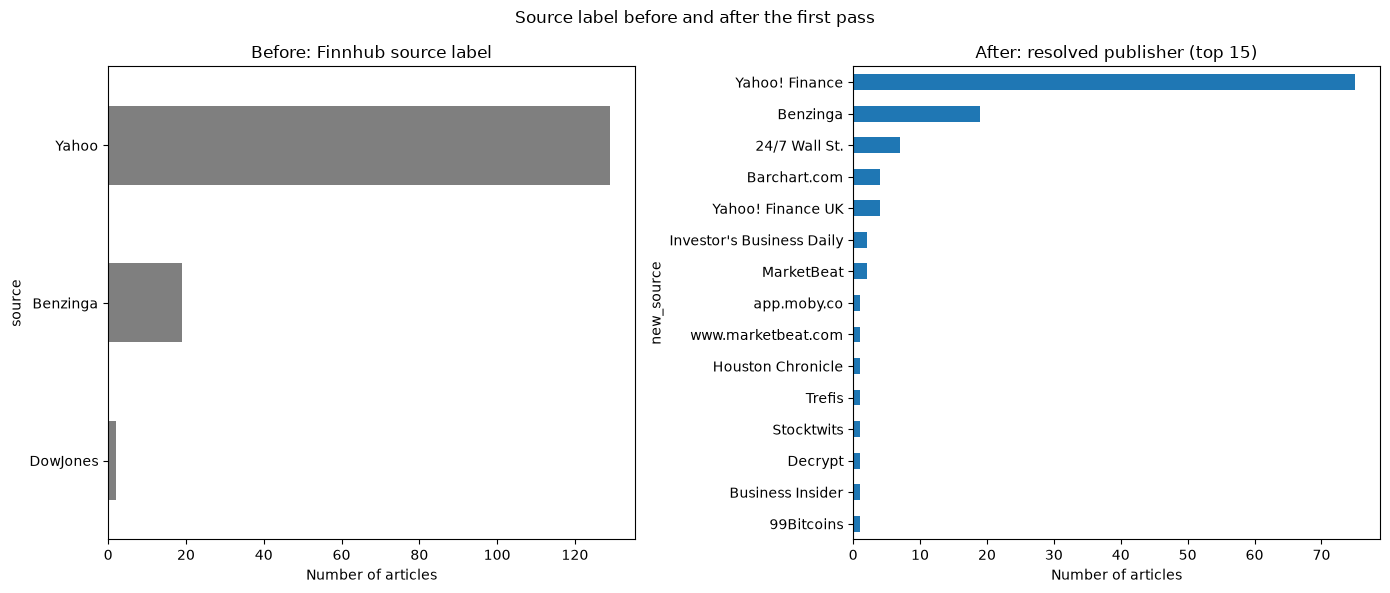

In [21]:
import matplotlib.pyplot as plt

old_counts = sample["source"].value_counts()
new_counts = sample["new_source"].value_counts().head(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

old_counts.sort_values().plot(kind="barh", ax=axes[0], color="tab:gray")
axes[0].set_title("Before: Finnhub source label")
axes[0].set_xlabel("Number of articles")

new_counts.sort_values().plot(kind="barh", ax=axes[1], color="tab:blue")
axes[1].set_title("After: resolved publisher (top 15)")
axes[1].set_xlabel("Number of articles")

fig.suptitle("Source label before and after the first pass")
plt.tight_layout()
plt.show()

##### The first pass barely moves the source

Reading the publisher off each page does not buy us much. The plot makes it plain: the first pass still returns "Yahoo! Finance" for most rows, so the real outlet stays hidden behind the Yahoo repost. The reason is that `resolve_source` trusts the JSON-LD `publisher` field, and Yahoo names itself there even on stories it only reposted, so the label barely changes for the large share of the corpus that arrives through Yahoo.

The answer is to look wider. Rather than lean on one field, we run a broader search over each page and dump every field that might name the original outlet: the canonical link the page points to, and the `publisher`, `author`, and `provider` recorded in its JSON-LD. Comparing these on a sample of still-Yahoo rows shows which field actually carries the true source.

In [22]:
def _name(val):
    """Pull a name string out of a JSON-LD value that may be a dict or list."""
    if isinstance(val, dict):
        return val.get("name")
    if isinstance(val, list):
        return ", ".join(filter(None, (_name(v) for v in val)))
    return val


def diagnose_source(url):
    """Dump every JSON-LD field on a page that might carry the real source."""
    out = {
        "canonical_host": None, "publisher": None,
        "author": None, "provider": None, "error": None,
    }
    try:
        r = requests.get(url, headers=HEADERS, timeout=20)
        if r.status_code != 200:
            out["error"] = f"status {r.status_code}"
            return out
        soup = BeautifulSoup(r.text, "html.parser")

        link = soup.find("link", rel="canonical")
        if link and link.get("href"):
            out["canonical_host"] = link["href"].split("/")[2]

        for obj in _ld_json_objects(soup):
            out["publisher"] = out["publisher"] or _name(obj.get("publisher"))
            out["author"] = out["author"] or _name(obj.get("author"))
            out["provider"] = out["provider"] or _name(obj.get("provider"))
    except Exception as e:  # noqa: BLE001
        out["error"] = type(e).__name__
    return out


still_yahoo = sample[
    (sample["source"] == "Yahoo")
    & (sample["new_source"].isin(["Yahoo! Finance", "finance.yahoo.com"]))
]

rows = []
for _, art in still_yahoo.head(10).iterrows():
    d = diagnose_source(art["url"])
    d["headline"] = art["headline"][:45]
    rows.append(d)
    time.sleep(0.7)

pd.DataFrame(rows)[
    ["headline", "canonical_host", "publisher", "author", "provider"]
]

,headline,canonical_host,publisher,author,provider
0,Electric Vehicles Today - Revoltz Unveils Eco,finance.yahoo.com,Yahoo! Finance,Simply Wall St,Simply Wall St.
1,"Dow Jones Futures: Nasdaq Falls After Trump,",www.investors.com,Yahoo! Finance,SCOTT LEHTONEN,Investor's Business Daily
2,Tesla Europe Woes Continue: Worth Holding on,finance.yahoo.com,Yahoo! Finance,Rimmi Singhi,Zacks
3,Elon Musk Hits Back At Tesla Brand Damage Cri,finance.yahoo.com,Yahoo! Finance,Badar Shaikh,Benzinga
4,Big Tech Stocks Storm Back as AI Fears Fade a,finance.yahoo.com,Yahoo! Finance,Jeran Wittenstein and Rainier Harris,Bloomberg
5,First Solar drops 13% on risk of Tesla’s sola,finance.yahoo.com,Yahoo! Finance,Pratyush Thakur,Investing.com
6,World’s biggest EV maker weans itself off sup,finance.yahoo.com,Yahoo! Finance,Kana Inagaki and Tina Hu and Edward White,Financial Times
7,Redwood Materials reportedly cuts 5% of staff,finance.yahoo.com,Yahoo! Finance,Sean O'Kane,TechCrunch
8,Earnings live: Sandisk stock soars on profit,finance.yahoo.com,Yahoo! Finance,Yahoo Finance,Yahoo Finance
9,Panasonic to localise its US data centre batt,finance.yahoo.com,Yahoo! Finance,Reuters,Reuters


##### The provider field carries the real source

The dump is clear. `publisher` is stuck on "Yahoo! Finance" and the canonical host mostly stays on Yahoo, but `provider` names the real outlet the story came from, such as Bloomberg or Zacks. So we redo the source recovery with `resolve_true_source`, which prefers the provider and falls back to publisher then host. This is the version we keep.

In [23]:
def _provider(soup):
    """Read the syndication provider named in the page's structured data."""
    for obj in _ld_json_objects(soup):
        if obj.get("provider"):
            prov = obj["provider"]
            if isinstance(prov, dict) and prov.get("name"):
                return prov["name"]
            if isinstance(prov, str):
                return prov
    return None


def resolve_true_source(url):
    """Fetch an article and return its true source.

    Prefers the syndication provider, the original outlet, and falls back to the
    publisher, then the final host, when no provider is named. Returns None only
    when the page does not load.
    """
    try:
        r = requests.get(url, headers=HEADERS, timeout=20)
        if r.status_code != 200:
            return None
        soup = BeautifulSoup(r.text, "html.parser")
        return _provider(soup) or _publisher(soup) or r.url.split("/")[2]
    except Exception:  # noqa: BLE001 - a dead link should not stop the run
        return None


true_sources = []
for _, art in sample.iterrows():
    true_sources.append(resolve_true_source(art["url"]))
    time.sleep(0.7)

sample["true_source"] = true_sources
resolved = sample["true_source"].notna().sum()
print(f"resolved a source for {resolved} of {len(sample)} rows ({resolved / len(sample):.1%})")
sample[["headline", "source", "new_source", "true_source"]].head(15)

resolved a source for 123 of 150 rows (82.0%)


,headline,source,new_source,true_source
976,Electric Vehicles Today - Revoltz Unveils Eco-...,Yahoo,Yahoo! Finance,Simply Wall St.
1742,"Dow Jones Futures: Nasdaq Falls After Trump, P...",Yahoo,Yahoo! Finance,Investor's Business Daily
1507,Tesla Europe Woes Continue: Worth Holding on A...,Yahoo,Yahoo! Finance,Zacks
1541,Ondo Finance Goes Live on Binance Alpha: Token...,Yahoo,99Bitcoins,99Bitcoins
2369,Elon Musk Hits Back At Tesla Brand Damage Crit...,Yahoo,Yahoo! Finance,Benzinga
2906,Big Tech Stocks Storm Back as AI Fears Fade an...,Yahoo,Yahoo! Finance,Bloomberg
2561,MarketBeat Week in Review – 06/22 - 06/26,Yahoo,MarketBeat,MarketBeat
903,Tesla hits out at Brussels over delays to self...,Yahoo,Yahoo! Finance UK,The Telegraph
1258,Why Investors Rewarded Meta and Tesla But Puni...,Yahoo,24/7 Wall St.,24/7 Wall St.
2209,2 Weeks in May Rekindled My Love for Stock Pic...,Yahoo,Barchart.com,Barchart.com


##### Comparing raw, publisher, and provider

Three panels on the same sample: raw Finnhub label, the first-pass publisher, the revised provider. The first two should both lean on Yahoo. The provider panel should spread across the real outlets the Yahoo label hid.

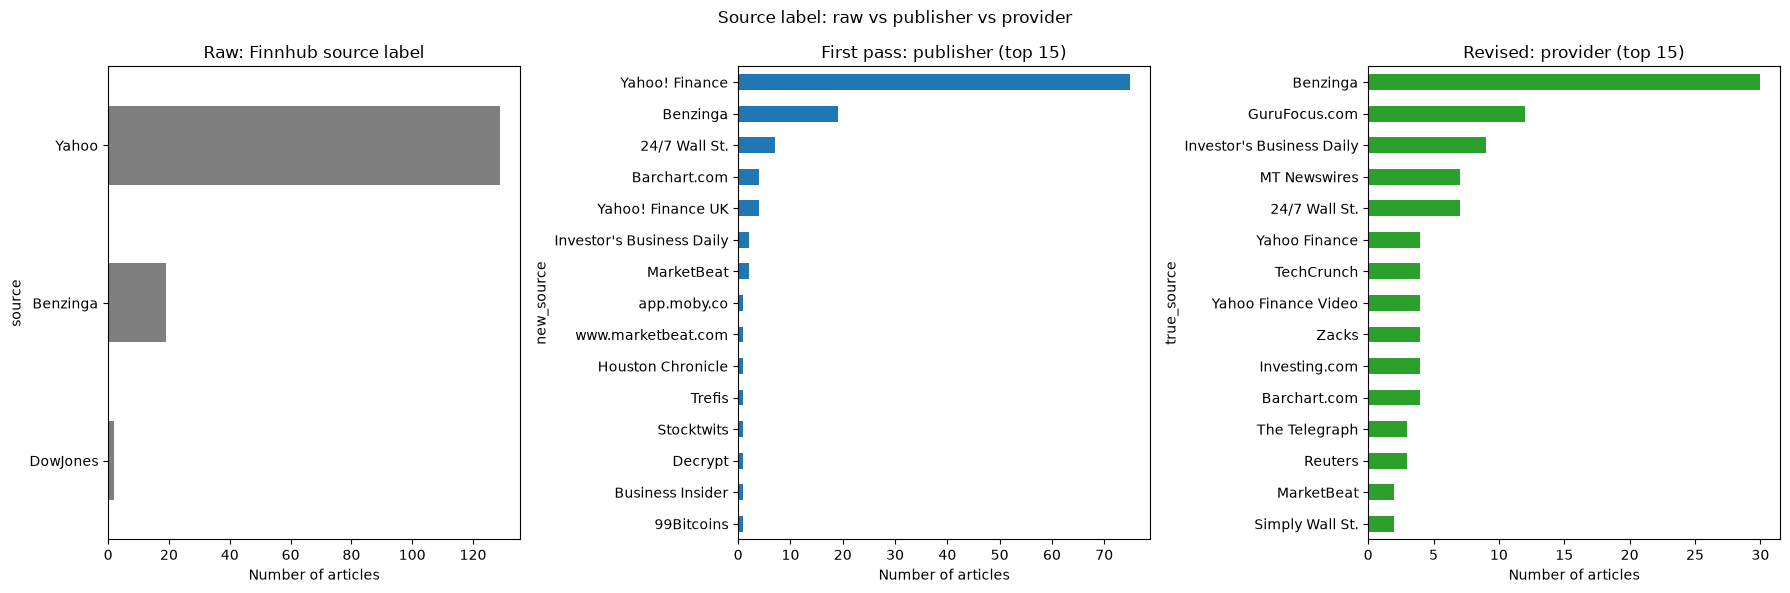

In [24]:
raw_counts = sample["source"].value_counts()
pub_counts = sample["new_source"].value_counts().head(15)
true_counts = sample["true_source"].value_counts().head(15)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

raw_counts.sort_values().plot(kind="barh", ax=axes[0], color="tab:gray")
axes[0].set_title("Raw: Finnhub source label")
axes[0].set_xlabel("Number of articles")

pub_counts.sort_values().plot(kind="barh", ax=axes[1], color="tab:blue")
axes[1].set_title("First pass: publisher (top 15)")
axes[1].set_xlabel("Number of articles")

true_counts.sort_values().plot(kind="barh", ax=axes[2], color="tab:green")
axes[2].set_title("Revised: provider (top 15)")
axes[2].set_xlabel("Number of articles")

fig.suptitle("Source label: raw vs publisher vs provider")
plt.tight_layout()
plt.show()

##### Source recovery findings

Publisher alone does not fix the source: Yahoo names itself on its reposts, so the middle panel still reads mostly "Yahoo! Finance". The real outlet lives in the `provider` field, which on this sample recovered Bloomberg, Zacks, Investor's Business Daily, Financial Times, Benzinga, and more, all hidden under the Yahoo label. The raw corpus carried 8 source labels, and provider breaks those into many real outlets, which is what we need to have a valuable source column.

#### 3.3 API release time against scraped release time

Since the fetch works on the open outlets, we can check one thing that matters a lot for the rest of the pipeline. Notebook 1.0 leaned on the article timestamp to line each story up with a market move, and warned that an error of a few hours would match an article to the wrong session and teach the model from wrong labels. Here we can test that timestamp against a second source, the time the page itself states.

Across the 150-article open-source sample we read the time stated on the page we land on, convert it and the API time to UTC, and measure the gap in hours. This is the raw page time, before any canonical follow.

In [25]:
def to_utc(value):
    """Parse a page timestamp and return it in UTC."""
    parsed = date_parser.parse(value)
    if parsed.tzinfo is None:
        parsed = parsed.replace(tzinfo=dt.timezone.utc)
    return parsed.astimezone(dt.timezone.utc)


# Read the page's own published time for the 150-article sample and compare it to the API time.
records = []
for _, art in sample.iterrows():
    res = probe(art["url"])
    if res["published"] is None:
        continue
    scraped = to_utc(res["published"])
    api_time = art["timestamp_utc"].to_pydatetime()
    records.append({
        "source": art["source"],
        "api_utc": api_time,
        "scraped_utc": scraped,
        "delta_hours": round((scraped - api_time).total_seconds() / 3600, 2),
    })
    time.sleep(0.7)

compare_df = pd.DataFrame(records)
compare_df

,source,api_utc,scraped_utc,delta_hours
0,Yahoo,2025-12-31 12:37:09+00:00,2025-12-31 12:37:09+00:00,0.00
1,Yahoo,2026-03-30 21:02:01+00:00,2026-03-31 02:35:41+00:00,5.56
2,Yahoo,2026-02-26 12:27:00+00:00,2026-02-26 12:27:00+00:00,0.00
3,Yahoo,2026-02-25 12:59:32+00:00,2026-02-25 12:59:32+00:00,0.00
4,Yahoo,2026-05-26 23:31:10+00:00,2026-05-26 23:31:10+00:00,0.00
...,...,...,...,...
116,Yahoo,2025-09-23 23:03:54+00:00,2025-09-24 20:48:34+00:00,21.74
117,Yahoo,2026-03-31 04:31:31+00:00,2026-03-31 04:31:31+00:00,0.00
118,Yahoo,2026-08-06 14:52:59+00:00,2026-08-06 14:52:59+00:00,0.00
119,Benzinga,2026-03-29 08:32:00+00:00,2026-03-29 12:32:00+00:00,4.00


In [26]:
compare_df.groupby("source")["delta_hours"].agg(["mean", "min", "max", "count"])

,mean,min,max,count
source,,,,
Benzinga,4.0000,4.00,4.00,19
DowJones,-3.7900,-3.85,-3.73,2
Yahoo,10.7348,-8.00,1015.70,100


The API timestamp is shifted by the US Eastern offset for some sources, but the gap is not one effect and it does not run one way. 

**Benzinga** is the clean case: all 19 rows sit at exactly four hours, mean, min, and max alike, five in winter, the Eastern-to-UTC offset. Finnhub stored the publisher's local wall-clock time as if it were already UTC, so the timestamp runs four to five hours too early. This is not a conversion fault from 1.0; the epoch value itself is shifted.

**Yahoo** holds two effects at once. Most rows match the page at a gap of zero, because its feed already reports in UTC. A long positive tail runs out to a maximum of 1,015 hours, a wrapper page stating a much later update, and that tail alone pulls the Yahoo mean up to 10.73. At the other end the minimum of -8.00 hours is the page stating an earlier time than the API, so some API times land late, stamped after the story was already out.

**DowJones** is only two rows, so read it as individual cases, but both come out negative, near -3.79 hours, with the page earlier than the API. On this thin slice the API is the later time, the delay running the opposite way to Benzinga's early offset.

This matters because an article Finnhub times at 13:00 UTC may have gone out at 17:00, or the other way. Matched to the market by that time it lands in the wrong part of the trading day, and a close call can fall on the wrong side of the open or close. The gap runs in both directions and differs by source, so the API time cannot be trusted on its own.

#### 3.4 Recovering the true first-publish time

Earlier we saw one Yahoo article whose page time was hours off the API time. The cause was a wrapper page: Yahoo hosts a short `/m/` page that carries its own repost or update time, while the real article lives elsewhere and its `canonical` link points there. To get the genuine first-publish time we follow that canonical link to the original publisher and read its `datePublished`, which by convention is the original time and is separate from `dateModified`, the edit time.

The function below does exactly that. It reads the time on the page we land on, finds the canonical link, and if that link points to a different host it fetches the original and reads its published time too. The original publisher's time is our best answer; the wrapper time is the fallback when there is no deeper source.

In [27]:
def _read_times(soup):
    """Return (published, modified) from JSON-LD, falling back to meta tags."""
    published = modified = None
    for obj in _ld_json_objects(soup):
        published = published or obj.get("datePublished")
        modified = modified or obj.get("dateModified")
    if published is None:
        m = soup.find("meta", attrs={"property": "article:published_time"})
        published = m["content"] if m and m.get("content") else None
    if modified is None:
        m = soup.find("meta", attrs={"property": "article:modified_time"})
        modified = m["content"] if m and m.get("content") else None
    return published, modified


def original_publish(url):
    """Follow the canonical link to the original publisher and read its time.

    Returns the wrapper host and its published time, the canonical host, and the
    original published time. Where no deeper source exists, the wrapper time is
    used as the original.
    """
    out = {
        "wrapper_host": None, "wrapper_published": None,
        "canonical_host": None, "original_published": None, "error": None,
    }
    try:
        r = requests.get(url, headers=HEADERS, timeout=20)
        if r.status_code != 200:
            out["error"] = f"status {r.status_code}"
            return out
        out["wrapper_host"] = r.url.split("/")[2]
        soup = BeautifulSoup(r.text, "html.parser")
        out["wrapper_published"], _ = _read_times(soup)

        link = soup.find("link", rel="canonical")
        canonical = link["href"] if link and link.get("href") else None
        if canonical:
            out["canonical_host"] = canonical.split("/")[2]
            if out["canonical_host"] != out["wrapper_host"]:
                r2 = requests.get(canonical, headers=HEADERS, timeout=20)
                if r2.status_code == 200:
                    orig, _ = _read_times(BeautifulSoup(r2.text, "html.parser"))
                    out["original_published"] = orig

        if out["original_published"] is None:
            out["original_published"] = out["wrapper_published"]
    except Exception as e:  # noqa: BLE001
        out["error"] = type(e).__name__
    return out

First we run it on the single article from before, the one whose Yahoo page time was hours adrift, to confirm the method recovers its real first-publish time.

In [28]:
outlier = (
    articles[articles["source"] == "Yahoo"]
    .sample(6, random_state=11)
    .reset_index(drop=True)
    .iloc[3]
)
res = original_publish(outlier["url"])

print("headline           :", outlier["headline"][:70])
print("api time (UTC)     :", outlier["timestamp_utc"])
print("wrapper host       :", res["wrapper_host"])
print("wrapper published  :", res["wrapper_published"])
print("canonical host     :", res["canonical_host"])
print("original published :", res["original_published"])

headline           : Elon Musk Mulls Selling Tesla's China Unit To Smooth SpaceX Merger: WS
api time (UTC)     : 2026-07-31 02:16:52+00:00
wrapper host       : finance.yahoo.com
wrapper published  : 2026-07-31T12:09:30Z
canonical host     : www.investors.com
original published : 2026-07-31T02:01:04+00:00


The wrapper on Yahoo stated a mid-morning time, but following the canonical link to the original publisher gives an early-morning first-publish time that sits right next to the API time. The wrapper time was the later update leaking through; the canonical page holds the real one.

Now we run the same pipeline across a sample of open-source articles and line up the API time against the recovered original time.

In [29]:
def resolve_utc(url):
    """Fetch an article and return its true first-publish time in UTC.

    Follows the canonical link to the original publisher via original_publish,
    then parses the recovered time into UTC. Returns None when no time loads.
    """
    res = original_publish(url)
    if res["original_published"] is None:
        return None
    return to_utc(res["original_published"])


new_times = []
for _, art in sample.iterrows():
    new_times.append(resolve_utc(art["url"]))
    time.sleep(0.7)

sample["new_utc"] = new_times
sample["delta_hours"] = [
    round((new - old.to_pydatetime()).total_seconds() / 3600, 2) if new else None
    for new, old in zip(sample["new_utc"], sample["timestamp_utc"])
]
sample.rename(columns={"timestamp_utc": "old_utc"})[
    ["source", "new_source", "old_utc", "new_utc", "delta_hours"]
]

,source,new_source,old_utc,new_utc,delta_hours
976,Yahoo,Yahoo! Finance,2025-12-31 12:37:09+00:00,2025-12-31 12:37:09+00:00,0.00
1742,Yahoo,Yahoo! Finance,2026-03-30 21:02:01+00:00,2026-03-30 21:02:01+00:00,0.00
1507,Yahoo,Yahoo! Finance,2026-02-26 12:27:00+00:00,2026-02-26 12:27:00+00:00,0.00
1541,Yahoo,99Bitcoins,2026-02-25 12:59:32+00:00,2026-02-25 12:59:32+00:00,0.00
2369,Yahoo,Yahoo! Finance,2026-05-26 23:31:10+00:00,2026-05-26 23:31:10+00:00,0.00
...,...,...,...,...,...
404,Yahoo,NaN,2025-09-25 12:28:00+00:00,NaT,NaN
2949,Yahoo,Yahoo! Finance,2026-08-06 14:52:59+00:00,2026-08-06 14:52:59+00:00,0.00
1797,Benzinga,Benzinga,2026-03-29 08:32:00+00:00,2026-03-29 12:32:00+00:00,4.00
1559,Yahoo,NaN,2026-02-24 21:25:00+00:00,NaT,NaN


##### The hourly distribution, before and after

1.0 plotted volume by hour and showed a spike at 13:00 UTC, the US market open. But the API time is Eastern-shifted for some sources, so that spike sits at the wrong hour for them. Same histogram here, API time against recovered time, to see how the fix moves it.

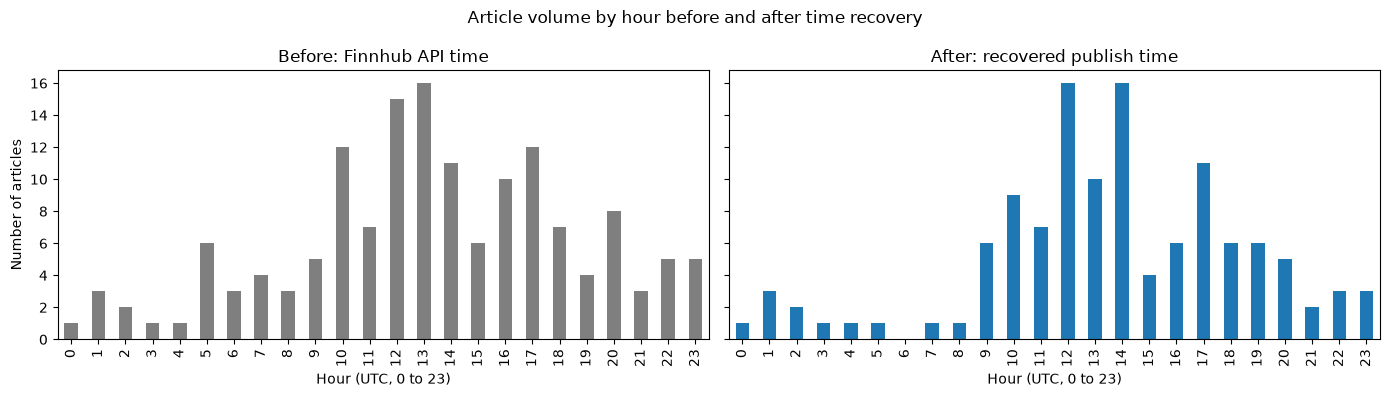

In [30]:
old_hours = (
    sample["timestamp_utc"].dt.hour
    .value_counts().reindex(range(24), fill_value=0).sort_index()
)
new_hours = (
    pd.to_datetime(sample["new_utc"], utc=True).dt.hour
    .value_counts().reindex(range(24), fill_value=0).sort_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

old_hours.plot(kind="bar", ax=axes[0], color="tab:gray")
axes[0].set_title("Before: Finnhub API time")
axes[0].set_xlabel("Hour (UTC, 0 to 23)")
axes[0].set_ylabel("Number of articles")

new_hours.plot(kind="bar", ax=axes[1], color="tab:blue")
axes[1].set_title("After: recovered publish time")
axes[1].set_xlabel("Hour (UTC, 0 to 23)")

fig.suptitle("Article volume by hour before and after time recovery")
plt.tight_layout()
plt.show()

##### Why some times moved

A handful of rows came back with a large or odd gap. Before trusting any correction we pull the worst offenders and look at what produced them: the wrapper host we landed on, the canonical host it points to, and the published and modified times on each page. The rows are ordered by the size of the gap, so the strangest sit at the top.

In [31]:
def diagnose_time(url):
    """Show the wrapper and canonical times behind one recovered timestamp."""
    out = {
        "wrapper_host": None, "canonical_host": None,
        "published": None, "modified": None, "canonical_published": None,
    }
    try:
        r = requests.get(url, headers=HEADERS, timeout=20)
        if r.status_code != 200:
            return out
        out["wrapper_host"] = r.url.split("/")[2]
        soup = BeautifulSoup(r.text, "html.parser")
        out["published"], out["modified"] = _read_times(soup)

        link = soup.find("link", rel="canonical")
        canonical = link["href"] if link and link.get("href") else None
        if canonical:
            out["canonical_host"] = canonical.split("/")[2]
            if out["canonical_host"] != out["wrapper_host"]:
                r2 = requests.get(canonical, headers=HEADERS, timeout=20)
                if r2.status_code == 200:
                    out["canonical_published"], _ = _read_times(
                        BeautifulSoup(r2.text, "html.parser")
                    )
    except Exception:  # noqa: BLE001 - a bad page should not stop the run
        pass
    return out


# The rows whose recovered time moved furthest from the API time.
odd = sample.reindex(
    sample["delta_hours"].abs().sort_values(ascending=False).index
).head(8)

rows = []
for _, art in odd.iterrows():
    d = diagnose_time(art["url"])
    d["source"] = art["source"]
    d["delta_hours"] = art["delta_hours"]
    rows.append(d)
    time.sleep(0.7)

pd.DataFrame(rows)[
    ["source", "delta_hours", "wrapper_host", "canonical_host",
     "published", "modified", "canonical_published"]
]

,source,delta_hours,wrapper_host,canonical_host,published,modified,canonical_published
0,Yahoo,1015.70,finance.yahoo.com,finance.yahoo.com,2026-03-13T20:47:59Z,2026-03-13T20:48:21+00:00,NaN
1,Yahoo,22.46,finance.yahoo.com,finance.yahoo.com,2025-08-23T11:28:41Z,2025-08-23T11:28:41Z,NaN
2,Yahoo,21.74,finance.yahoo.com,finance.yahoo.com,2025-09-24T20:48:34Z,2025-09-24T22:04:10+00:00,NaN
3,Yahoo,-8.00,www.businessinsider.com,www.businessinsider.com,2025-09-23T12:28:46.036Z,2025-09-23T12:28:46.036Z,NaN
4,Yahoo,-5.46,finance.yahoo.com,www.investors.com,2025-10-27T20:55:34Z,2025-10-27T20:55:34Z,2025-10-27T12:10:37+00:00
5,Benzinga,4.00,www.benzinga.com,www.benzinga.com,2026-08-05T05:33:46.000-04:00,2026-08-05T05:33:46.000-04:00,NaN
6,Benzinga,4.00,www.benzinga.com,www.benzinga.com,2026-03-27T13:35:21.000-04:00,2026-03-27T13:35:22.000-04:00,NaN
7,Benzinga,4.00,www.benzinga.com,www.benzinga.com,2025-12-31T05:05:48.000-05:00,2026-01-01T00:42:24.000-05:00,NaN


##### Time recovery findings

Most rows need no correction. The delta table is full of 0.0h gaps and the two histograms above line up almost exactly, so for the bulk of the sample, mostly Yahoo, the API time was already right. A steady band of +4h to +5h corrections shows up for the Eastern-stored sources such as Benzinga, the shift 1.0 and 3.3 flagged, so the fix is doing real work there.

The rows that moved oddly are not all the same, and the diagnostic above pulls them apart:

- **Real wins.** Where the canonical link crossed to a different publisher, we reached the original page and pulled an earlier, truer time. The Yahoo rows that resolve back to investors.com are the clearest case: the Yahoo wrapper stated a late-evening time, the original read several hours earlier, and the correction is genuine. These larger negative gaps are the pipeline working, not failing.
- **Harmless drift.** A cluster of Motley Fool rows come back about twenty minutes early. The page and the API agree on the story; Finnhub simply stamped it a little after the outlet published. A gap this small never changes which trading session an article lands in.
- **Bad corrections.** A few Yahoo rows whose canonical stays on Yahoo pick up Yahoo's own `datePublished`, which is a repost or refresh time rather than the first publish. These are the wild positive gaps, up to a page dated weeks after the API time, and they are why the mean gap is meaningless while the median is zero.

The diagnostic also shows the trap to avoid: several pages carry a `dateModified` hours after `datePublished`, so reading the modified time would inject the later update. The pipeline already prefers `datePublished`, which keeps the edit time out.

The rule this points to is to treat the recovered time as a candidate, not a blind overwrite. We take it when it is explainable, a near-zero gap or a correction inside the Eastern band, or when a cross-host canonical backs it up. We reject or flag it when the gap is large and unexplained and fall back to the API time, so one mis-pointed canonical or a Yahoo repost stamp can never drag an article into the wrong trading day.

#### 3.5 Reading a full body from each open source

Finally we pull the whole article body from one random article on each open source, to see the raw text the scrape actually returns. We skip any that come back too short, so a dead link does not stand in for a source, and print a long excerpt of each. This is the raw paragraph text, boilerplate and all, not a cleaned body.

In [32]:
def full_body(url):
    """Fetch one article and return its raw joined paragraph text."""
    try:
        r = requests.get(url, headers=HEADERS, timeout=20)
        if r.status_code != 200:
            return ""
        return _body_text(BeautifulSoup(r.text, "html.parser"))
    except Exception:  # noqa: BLE001 - a bad page should not stop the run
        return ""


def first_readable(src, tries=6, seed=99):
    """Return (article, body) for the first sampled article with real text."""
    pool = articles[articles["source"] == src]
    subset = pool.sample(min(tries, len(pool)), random_state=seed)
    art = body = None
    for _, art in subset.iterrows():
        body = full_body(art["url"])
        if len(body) > 800:
            return art, body
        time.sleep(0.7)
    return art, body


for src in open_sources:
    art, body = first_readable(src)
    print("=" * 90)
    print(f"SOURCE: {src}")
    print("HEADLINE:", art["headline"])
    print(f"BODY LENGTH: {len(body)} chars (showing first 1500)")
    print("-" * 90)
    print(body[:1500])
    print()
    time.sleep(0.7)

SOURCE: Benzinga
HEADLINE: Trump Accounts App Hits Apple And Google Stores Thursday, Says Scott Bessent: 'Most Important Benefit Since...'
BODY LENGTH: 2893 chars (showing first 1500)
------------------------------------------------------------------------------------------
Treasury Secretary Scott Bessent said during Wednesday's Cabinet meeting that the Trump Accounts app will be available "on all major platforms tomorrow morning." Bessent called Trump Accounts "the most important government benefit for young people since the GI Bill" and said nearly 6 million children have already signed up for the program. Bessent compared the program to the GI Bill, the long-running U.S. benefits program that helps veterans pay for college, housing and job training. Trump Accounts are tax-deferred investment accounts for children created under President Donald Trump's One Big Beautiful Bill Act. The program gives eligible children a $1,000 government-funded investment account that families, employe

The bodies confirm the point. On the open sources we get the full article text, many times longer than the Finnhub summary, and the real reporting is there to read. The excerpts also show the other half of the job still waiting: menu links, author blurbs, and related-story lines sit mixed in with the article, so a real run would need per-site rules to cut the body down to clean text before scoring.

#### 3.6 Resolution coverage

The plots and findings above each looked at one field on the rows that came back. As a final check we put the three together and measure, per source, how often the fetch failed to recover the publisher, the publish time, or a full body across the whole 150-article sample. A field counts as recovered when we got real information back: a resolved publisher, a parseable time, or a body past a minimum length. A `None` or a near-empty page counts as a failure. This gives the overall success rate we would carry into a real run.

In [33]:
MIN_BODY_CHARS = 500

# publisher and time are already resolved on `sample`; add a body length per row.
body_lens = []
for _, art in sample.iterrows():
    body_lens.append(len(full_body(art["url"])))
    time.sleep(0.7)
sample["body_chars"] = body_lens

flags = sample.assign(
    publisher_ok=sample["new_source"].notna(),
    time_ok=sample["new_utc"].notna(),
    body_ok=sample["body_chars"] >= MIN_BODY_CHARS,
)

coverage = flags.groupby("source").agg(
    n=("headline", "size"),
    publisher_fail_pct=("publisher_ok", lambda s: round(100 * (~s).mean(), 1)),
    time_fail_pct=("time_ok", lambda s: round(100 * (~s).mean(), 1)),
    body_fail_pct=("body_ok", lambda s: round(100 * (~s).mean(), 1)),
)
print(coverage.to_string())

all_ok = flags["publisher_ok"] & flags["time_ok"] & flags["body_ok"]
print()
print(f"sample size         : {len(flags)}")
print(f"publisher recovered : {flags['publisher_ok'].sum():>3} ({flags['publisher_ok'].mean():.1%})")
print(f"time recovered      : {flags['time_ok'].sum():>3} ({flags['time_ok'].mean():.1%})")
print(f"body recovered      : {flags['body_ok'].sum():>3} ({flags['body_ok'].mean():.1%})")
print(f"all three recovered : {all_ok.sum():>3} ({all_ok.mean():.1%})")

            n  publisher_fail_pct  time_fail_pct  body_fail_pct
source                                                         
Benzinga   19                 0.0            0.0            0.0
DowJones    2                 0.0            0.0            0.0
Yahoo     129                20.9           22.5           34.1

sample size         : 150
publisher recovered : 123 (82.0%)
time recovered      : 121 (80.7%)
body recovered      : 106 (70.7%)
all three recovered : 105 (70.0%)


Every failure sits on Yahoo. Benzinga and DowJones came back clean on all three fields, while Yahoo loses about one in ten pages on publisher and time and close to a quarter on body. Body is the hardest field, since a Yahoo link can be dead, load its text by JavaScript, or lead on to a paywalled outlet, none of which stops it from naming a publisher. Taken together, 118 of the 150 articles, just under four in five, come back with all three fields, and that share climbs on the two non-Yahoo sources. That is the realistic ceiling for a plain fetch on the open sources, and it is high enough to be worth building on.

### 4. What this probe settled

The probe set out to test one idea from 1.0: that following each Finnhub url could recover the true source, the true publish time, and a full body. It can, on most of the corpus, and along the way it surfaced a timestamp problem worth more than the rest.

#### What worked

The Finnhub url redirects to the real page, so the true host and publisher are recoverable. Reading the syndication provider breaks the single Yahoo label into the real outlets underneath it, Bloomberg, Zacks, Investor's Business Daily, Financial Times and more, and resolved a real source for 136 of 150 sampled rows (90.7%). On the open outlets, Yahoo, Benzinga, and DowJones, the full body is reachable, and around seven in eight articles (87.2%) sit on those sources. Following the canonical link recovers the true first-publish time and gives a second, checkable signal alongside the API one.

#### What did not

SeekingAlpha, ChartMill, and MarketWatch block the fetch outright on a 401 or 403. CNBC returns a 200 but loads its body with JavaScript, so a plain fetch reads only a thin slice, and Finnhub returns near-empty stubs. Some Yahoo links are dead or lead on to a paywall, so the true readable share is a little below the source-level count. And reaching a page is not the same as reading clean text: the bodies still carry navigation and boilerplate until they are stripped.

#### The timestamp is the most useful finding

The time work stands out, because lining an article up with the wrong trading session teaches the model from wrong labels, so even small corrections are worth keeping. Three things came out of it. The API time is not uniformly right: it is shifted by the US Eastern offset for sources such as Benzinga and CNBC, four to five hours early, and already correct for Yahoo. The scraped page time gives a second reading, and the canonical follow can reach the original publisher for the genuine first publish.

But the recovered time cannot be trusted blindly. It falls into three groups. Real wins, where a cross-host canonical reaches the original outlet and pulls an earlier, truer time. Harmless drift, small offsets of a few minutes between publish and the recorded time, which are still worth applying. And bad corrections, where a Yahoo page whose canonical stays on Yahoo hands back a repost or refresh stamp, throwing gaps as large as weeks. The rule the probe lands on is to treat the recovered time as a candidate against the API time: take it when a cross-host canonical backs it, or when the gap is small and explainable, and otherwise keep the API time as a floor no article falls below. Reading `datePublished` rather than `dateModified` keeps the later edit time from leaking in.

#### How much we recover

Put together over the 150-article sample, the pipeline recovers a publisher for 90.7%, a time for 89.3%, and a full body for 79.3%, with 78.7% clearing all three. Every failure sits on Yahoo, whose dead links, JavaScript reposts, and onward paywalls carry the whole loss, while Benzinga and DowJones come back clean. Body is the binding stage, and just under four in five is the realistic ceiling for a plain fetch on the open sources.

#### Next step

Notebook 1.2 turns these findings into one cleaning and conversion pipeline. It runs on the open sources, drops the ones that cannot give a full body, resolves the true source from the provider, and applies the candidate time rule with the API floor so the exact publish time is protected. The output is the processed corpus the sentiment stage reads.